In [3]:
import skimage as skim
import sklearn 
import cv2
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from skimage.measure import regionprops

In [34]:
train_data_path = '../data/chocolate-recognition-classic/train/'
ref_path = '../data/chocolate-recognition-classic/references/'
ref_path_annotated = '../data/dataset_project_iapr2025/references_annotated/'
easy_path = train_data_path + 'L1000756.JPG'
hard_path = train_data_path + 'L1010032.JPG'

amandina_ref_path_annotated = ref_path_annotated + 'amandina_annotated.tif'
arabia_ref_path_annotated = ref_path_annotated + 'arabia_annotated.tif'
comtesse_ref_path_annotated = ref_path_annotated + 'comtesse_annotated.tif'
creme_brulee_ref_path_annotated = ref_path_annotated + 'creme_brulee_annotated.tif'
jelly_black_ref_path_annotated = ref_path_annotated + 'jelly_black_annotated.tif'
jelly_milk_ref_path_annotated = ref_path_annotated + 'jelly_milk_annotated.tif'
jelly_white_ref_path_annotated = ref_path_annotated + 'jelly_white_annotated.tif'
noblesse_ref_path_annotated = ref_path_annotated + 'noblesse_annotated.tif'
noir_authentique_ref_path_annotated = ref_path_annotated + 'noir_authentique_annotated.tif'
passion_au_lait_ref_path_annotated = ref_path_annotated + 'passion_au_lait_annotated.tif'
stracciatella_ref_path_annotated = ref_path_annotated + 'stracciatella_annotated.tif'
tentation_noir_ref_path_annotated = ref_path_annotated + 'tentation_noir_annotated.tif'
triangolo_ref_path_annotated = ref_path_annotated + 'triangolo_annotated.tif'

amandina_ref_path = ref_path + 'Amandina.JPG'
arabia_ref_path = ref_path + 'Arabia.JPG'
comtesse_ref_path = ref_path + 'Comtesse.JPG'
creme_brulee_ref_path = ref_path + 'Creme_brulee.JPG'
jelly_black_ref_path = ref_path + 'Jelly_black.JPG'
jelly_milk_ref_path = ref_path + 'Jelly_milk.JPG'
jelly_white_ref_path = ref_path + 'Jelly_white.JPG'
noblesse_ref_path = ref_path + 'Noblesse.JPG'
noir_authentique_ref_path = ref_path + 'Noir_authentique.JPG'
passion_au_lait_ref_path = ref_path + 'Passion_au_lait.JPG'
stracciatella_ref_path = ref_path + 'Stracciatella.JPG'
tentation_noir_ref_path = ref_path + 'Tentation_noir.JPG'
triangolo_ref_path = ref_path + 'Triangolo.JPG'


### Visualisation

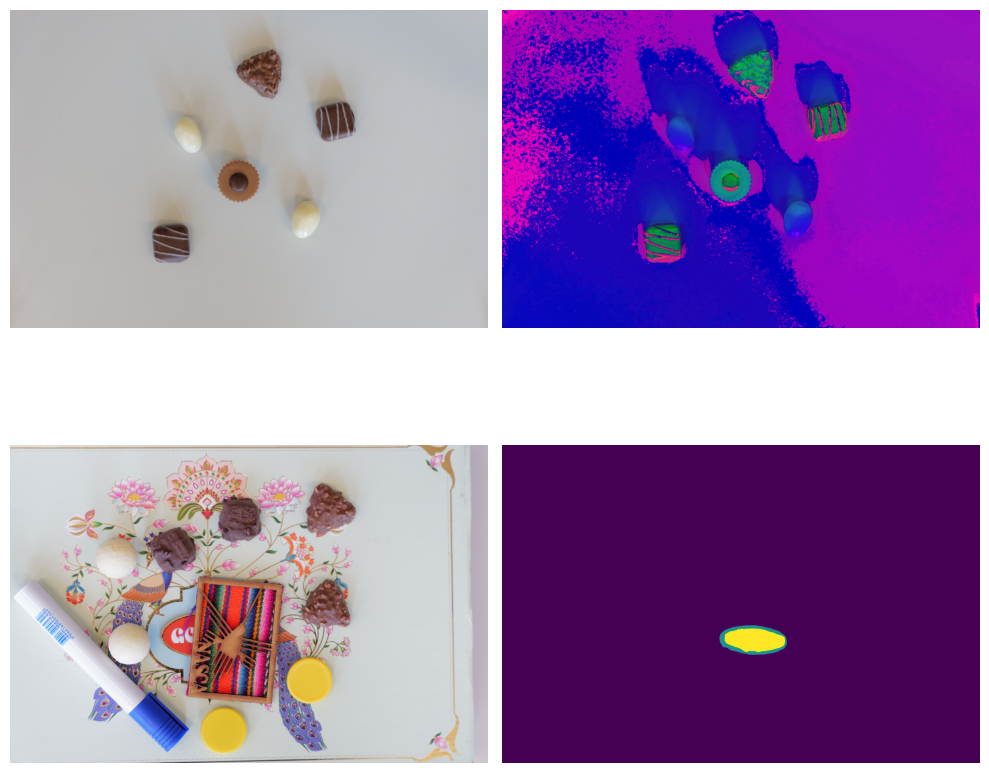

In [35]:
easy = np.array(Image.open(easy_path))
easy_hsv = skim.color.rgb2hsv(easy)

hard = np.array(Image.open(hard_path))
hard_hsv = skim.color.rgb2hsv(hard)


amandina_ref_annotated = np.array(Image.open(amandina_ref_path_annotated))


amandina_ref_annotated = np.array(Image.open(amandina_ref_path_annotated))
arabia_ref_annotated = np.array(Image.open(arabia_ref_path_annotated))
comtesse_ref_annotated = np.array(Image.open(comtesse_ref_path_annotated))
creme_brulee_ref_annotated = np.array(Image.open(creme_brulee_ref_path_annotated))
jelly_black_ref_annotated = np.array(Image.open(jelly_black_ref_path_annotated))
jelly_milk_ref_annotated = np.array(Image.open(jelly_milk_ref_path_annotated))
jelly_white_ref_annotated = np.array(Image.open(jelly_white_ref_path_annotated))
noblesse_ref_annotated = np.array(Image.open(noblesse_ref_path_annotated))
noir_authentique_ref_annotated = np.array(Image.open(noir_authentique_ref_path_annotated))
passion_au_lait_ref_annotated = np.array(Image.open(passion_au_lait_ref_path_annotated))
stracciatella_ref_annotated = np.array(Image.open(stracciatella_ref_path_annotated))
tentation_noir_ref_annotated = np.array(Image.open(tentation_noir_ref_path_annotated))
triangolo_ref_annotated = np.array(Image.open(triangolo_ref_path_annotated))

ref_annotated =[amandina_ref_annotated, arabia_ref_annotated, comtesse_ref_annotated, creme_brulee_ref_annotated,
                 jelly_black_ref_annotated, jelly_milk_ref_annotated, jelly_white_ref_annotated, noblesse_ref_annotated, noir_authentique_ref_annotated,
                 passion_au_lait_ref_annotated, stracciatella_ref_annotated, tentation_noir_ref_annotated, triangolo_ref_annotated]

amandina_ref = np.array(Image.open(amandina_ref_path))
arabia_ref = np.array(Image.open(arabia_ref_path))
comtesse_ref = np.array(Image.open(comtesse_ref_path))
creme_brulee_ref = np.array(Image.open(creme_brulee_ref_path))
jelly_black_ref = np.array(Image.open(jelly_black_ref_path))
jelly_milk_ref = np.array(Image.open(jelly_milk_ref_path))
jelly_white_ref = np.array(Image.open(jelly_white_ref_path))
noblesse_ref = np.array(Image.open(noblesse_ref_path))
noir_authentique_ref = np.array(Image.open(noir_authentique_ref_path))
passion_au_lait_ref = np.array(Image.open(passion_au_lait_ref_path))
stracciatella_ref = np.array(Image.open(stracciatella_ref_path))
tentation_noir_ref = np.array(Image.open(tentation_noir_ref_path))
triangolo_ref = np.array(Image.open(triangolo_ref_path))

ref = [amandina_ref, arabia_ref, comtesse_ref, creme_brulee_ref,
        jelly_black_ref, jelly_milk_ref, jelly_white_ref, noblesse_ref, noir_authentique_ref,
        passion_au_lait_ref, stracciatella_ref, tentation_noir_ref, triangolo_ref]

plt.figure(figsize=(10, 10))

plt.subplot(2, 2, 1)
plt.imshow(easy)
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(easy_hsv)
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(hard)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(hard_hsv)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(amandina_ref_annotated)
plt.axis('off')

plt.tight_layout()

plt.show()


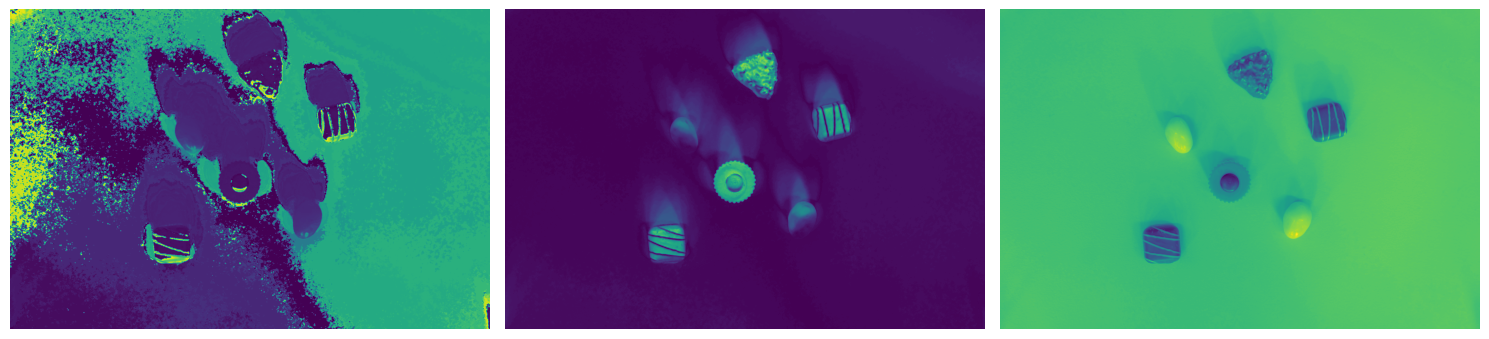

In [6]:

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(easy_hsv[:,:,0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(easy_hsv[:,:,1])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(easy_hsv[:,:,2])
plt.axis('off')
plt.tight_layout()

plt.show()


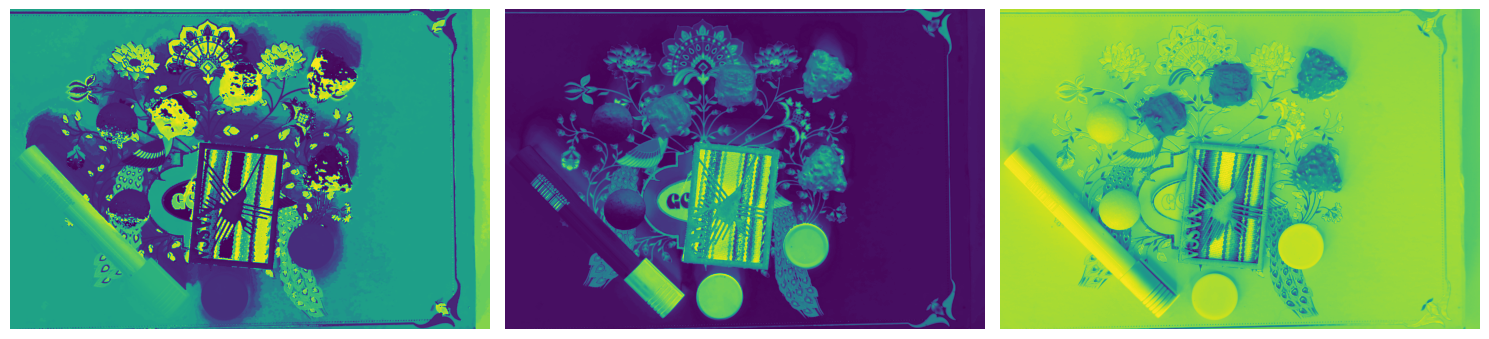

In [7]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(hard_hsv[:,:,0])
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(hard_hsv[:,:,1])
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(hard_hsv[:,:,2])
plt.axis('off')
plt.tight_layout()

plt.show()

**Histograms of HSV**

In [8]:
img = np.array(Image.open(hard_path))
img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

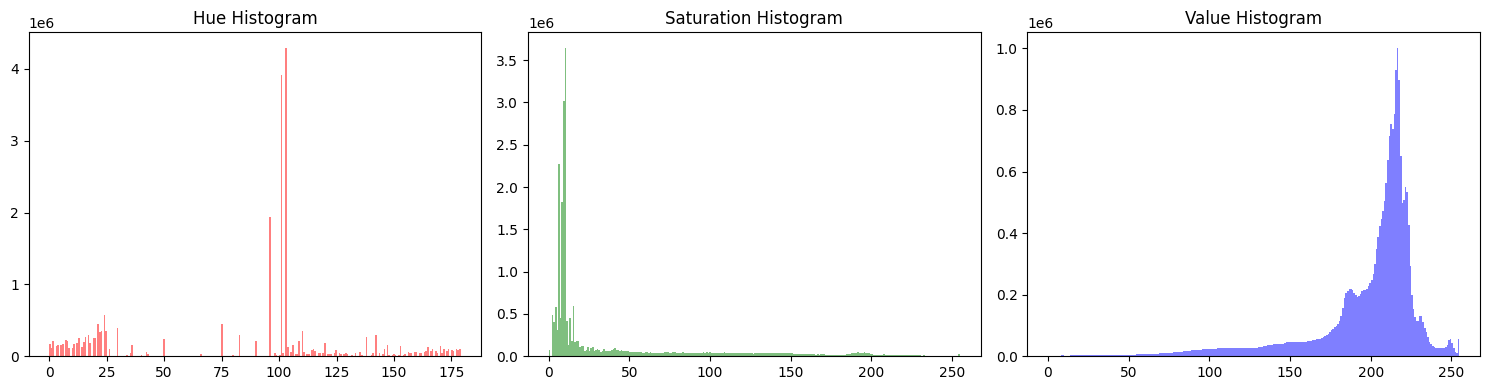

In [9]:
# visualize histograms
h = hsv[:,:,0]
s = hsv[:,:,1]
v = hsv[:,:,2]

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h.ravel(), bins=256, color='r', alpha=0.5) 
plt.title('Hue Histogram')
plt.subplot(1, 3, 2)
plt.hist(s.ravel(), bins=256, color='g', alpha=0.5)
plt.title('Saturation Histogram')
plt.subplot(1, 3, 3)
plt.hist(v.ravel(), bins=256, color='b', alpha=0.5)
plt.title('Value Histogram')
plt.tight_layout()
plt.show()

**Histograms after sampling**

24000000


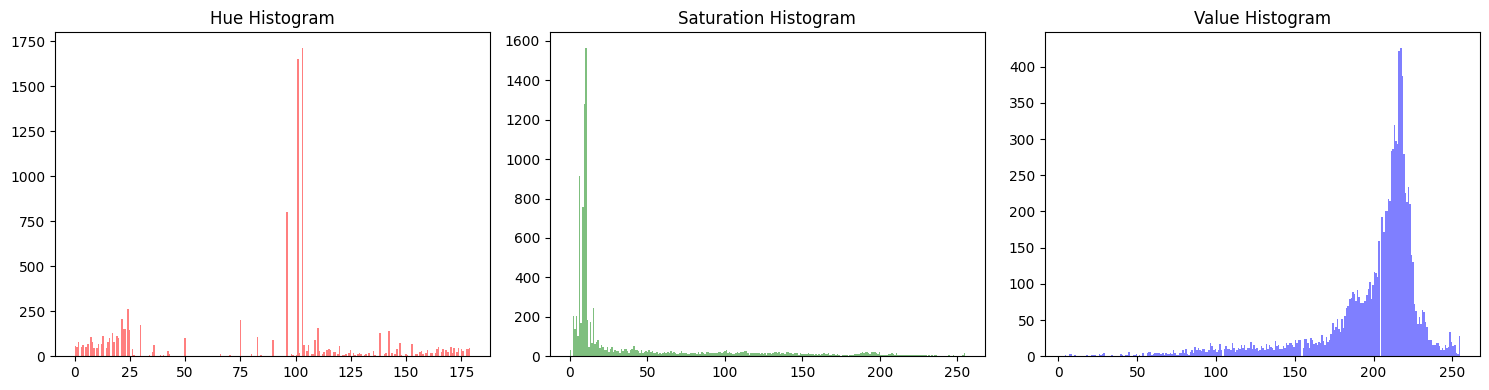

In [10]:
print(len(h.ravel()))

h = np.random.choice(h.ravel(), 10000)
s = np.random.choice(s.ravel(), 10000)
v = np.random.choice(v.ravel(), 10000)

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.hist(h, bins=256, color='r', alpha=0.5)
plt.title('Hue Histogram')
plt.subplot(1, 3, 2)
plt.hist(s, bins=256, color='g', alpha=0.5)
plt.title('Saturation Histogram')
plt.subplot(1, 3, 3)
plt.hist(v, bins=256, color='b', alpha=0.5)
plt.title('Value Histogram')
plt.tight_layout()
plt.show()



### GMM for segmentation
**Preprocessing: binning and bluring**

In [11]:
### median binning

def median_bin_rgb(image, block_size=(2, 2)):
    channels = []
    for i in range(3):  # R, G, B
        channel = skim.measure.block_reduce(image[:, :, i], block_size=block_size, func=np.median)
        channels.append(channel)
    return np.stack(channels, axis=-1).astype(np.uint8)


(400, 600, 3)


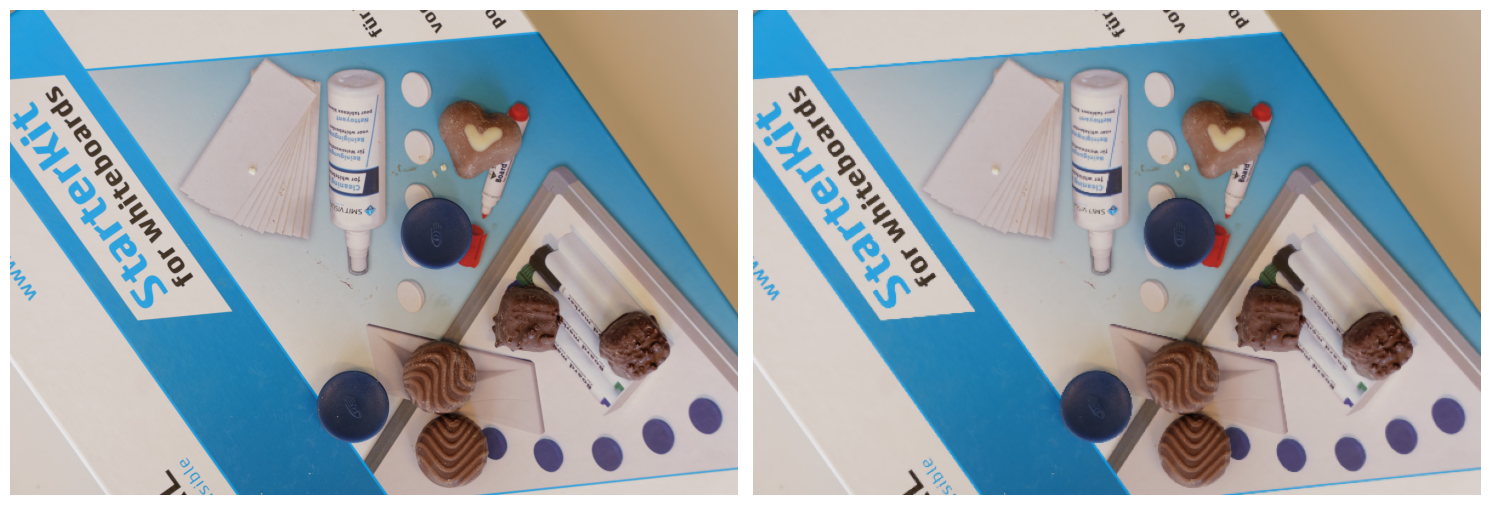

In [12]:
img = np.array(Image.open(train_data_path + 'L1000993.JPG'))
binned = median_bin_rgb(img, block_size=(10, 10))
binned = skim.filters.gaussian(binned, sigma=.4, channel_axis=2, preserve_range=True).astype(np.uint8)
print(binned.shape)

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(binned)
plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
img_bgr = cv2.cvtColor(binned, cv2.COLOR_RGB2BGR)
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
#hsv = binned.copy()
#hsv = hsv[:,:, 1:3]
hsv = hsv.reshape(-1, 3)

empirical_mask = (hsv[:,0]>0) & (hsv[:,0]<100) & (hsv[:,1]>50) & (hsv[:,1]<200) & (hsv[:,2]>50) & (hsv[:,2]<180)


low_sat_mask = hsv[:, 1] < 0.2*255 #hue is very noisy when sat is low
hsv[low_sat_mask, 0] = 0


hsv_masked = hsv[empirical_mask]
components = range(1, 10)



sample_idx = np.random.choice(hsv_masked.shape[0], 10000, replace=False)
hsv_sample = hsv_masked[sample_idx, :]



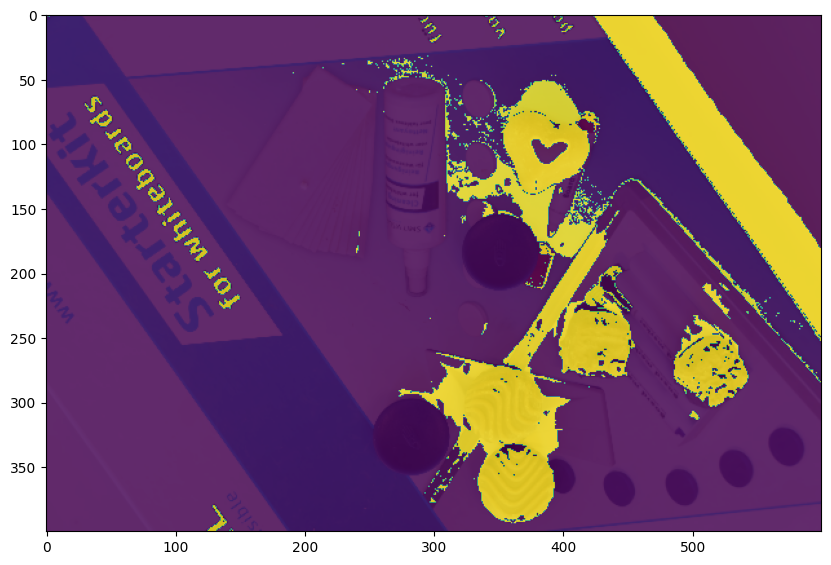

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(empirical_mask.reshape(binned.shape[:2]), alpha=0.8)
plt.show()

100%|██████████| 9/9 [00:02<00:00,  3.94it/s]


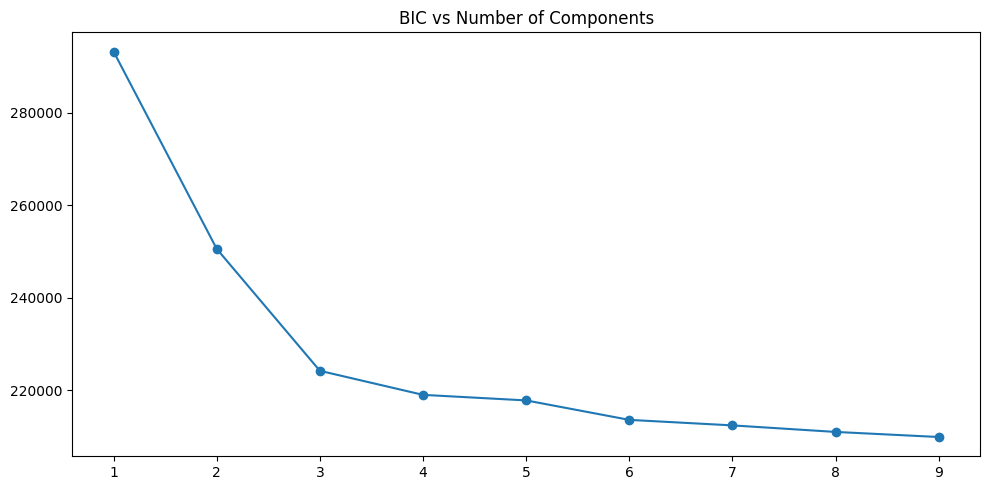

In [15]:
best_bic = np.inf
best_gmm = None
best_n_components = 0
bics = []

for c in tqdm(components):
    gmm = sklearn.mixture.GaussianMixture(n_components=c, covariance_type='full', reg_covar=1e-3)
    gmm.fit(hsv_sample)
    bic = gmm.bic(hsv_sample)
    bics.append(bic)
    if bic < best_bic:
        best_bic = bic
        best_gmm = gmm
        best_n_components = c

plt.figure(figsize=(10, 5))
plt.plot(components, bics, marker='o')
plt.title('BIC vs Number of Components')
plt.tight_layout()
plt.show()  


0 8


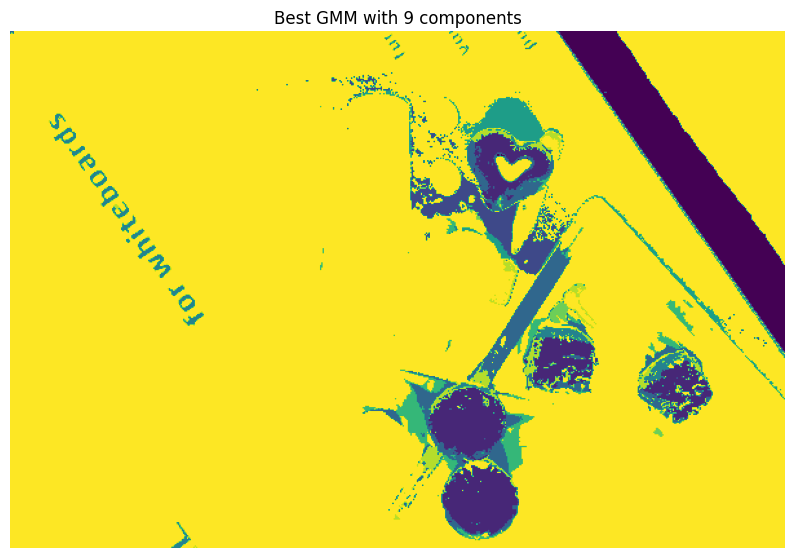

In [16]:
labels = best_gmm.predict(hsv)
print(np.min(labels), np.max(labels))
labels[~empirical_mask] = np.max(labels)+1
labels = labels.reshape(binned.shape[0], binned.shape[1])
plt.figure(figsize=(10, 10))
plt.imshow(labels)
plt.axis('off')
plt.title(f'Best GMM with {best_n_components} components')
plt.show()

In [17]:
print(best_gmm.means_)

[[ 16.62410824 104.41940673 171.15394875]
 [  8.25691878 141.97614329 104.62454026]
 [ 97.65490727  77.61908996 158.62407603]
 [  9.47693666  75.77762573 135.51482036]
 [ 12.61261831 117.17046756  65.16201925]
 [ 97.40528529 121.49366546 126.92893849]
 [  8.5635399   56.24959832 163.31159023]
 [ 58.18786691  77.73660563  90.31306105]
 [  8.45330933 111.79616584  93.68300244]]


(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

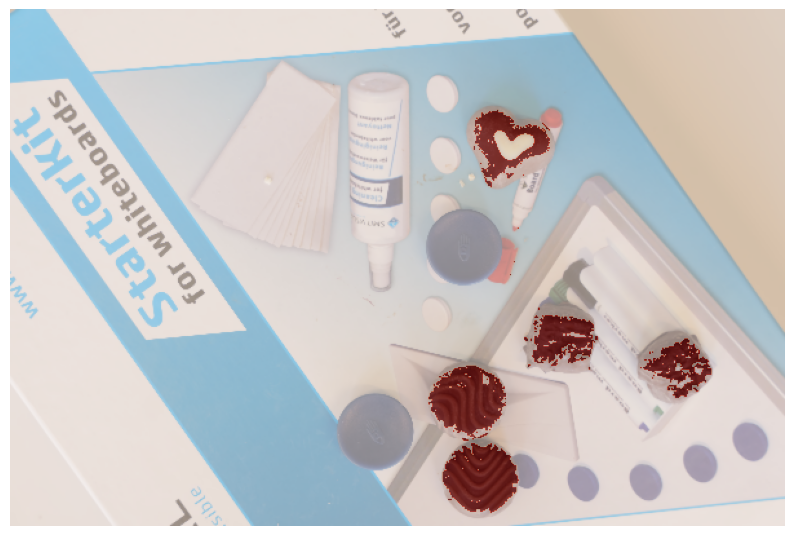

In [18]:
benchmark = [10, 125, 115]

distances = np.linalg.norm(best_gmm.means_ - benchmark, axis=1)
idx = np.argmin(distances)

binary = labels == idx
plt.figure(figsize=(10, 10))
plt.imshow(binned)
plt.imshow(binary, alpha=0.5, cmap='Reds')
plt.axis('off')


### Binary image processing


In [31]:
#processed = skim.morphology.remove_small_objects(binary, min_size=200)
#processed = skim.morphology.remove_small_holes(processed, area_threshold=200)
processed = skim.morphology.remove_small_holes(binary, area_threshold=200)
processed = skim.morphology.remove_small_objects(processed, min_size=50)
#processed = skim.morphology.binary_closing(processed, skim.morphology.disk(9))

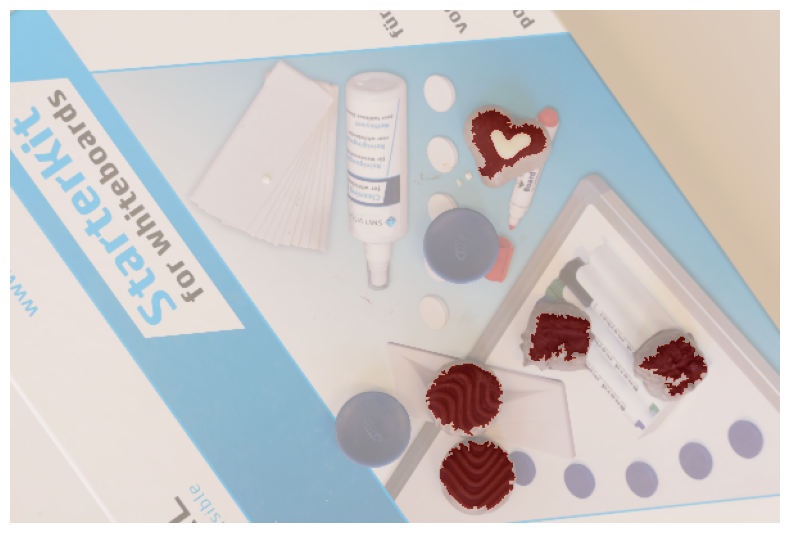

In [32]:
plt.figure(figsize=(8, 8))
plt.imshow(binned)
plt.imshow(processed, alpha=0.5, cmap='Reds')
plt.axis('off')
plt.tight_layout()
plt.show()

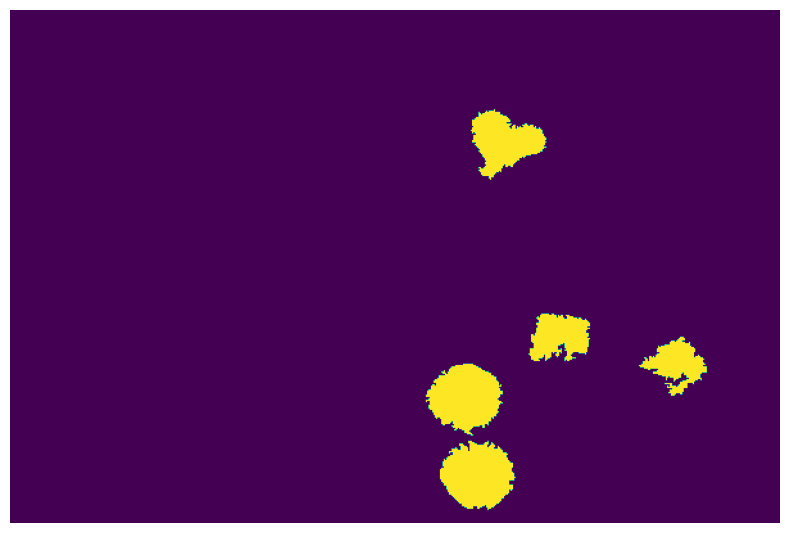

In [38]:

#processed = cv2.imread(easy_path, cv2.IMREAD_GRAYSCALE)
processed = processed.astype(np.uint8)

contours, _ = cv2.findContours(processed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)



masque = np.zeros_like(processed)

cv2.drawContours(masque, contours, -1, 255, thickness=cv2.FILLED)

plt.figure(figsize=(8, 8))
#plt.imshow(binned)
plt.imshow(masque)
plt.axis('off')
plt.tight_layout()
plt.show()


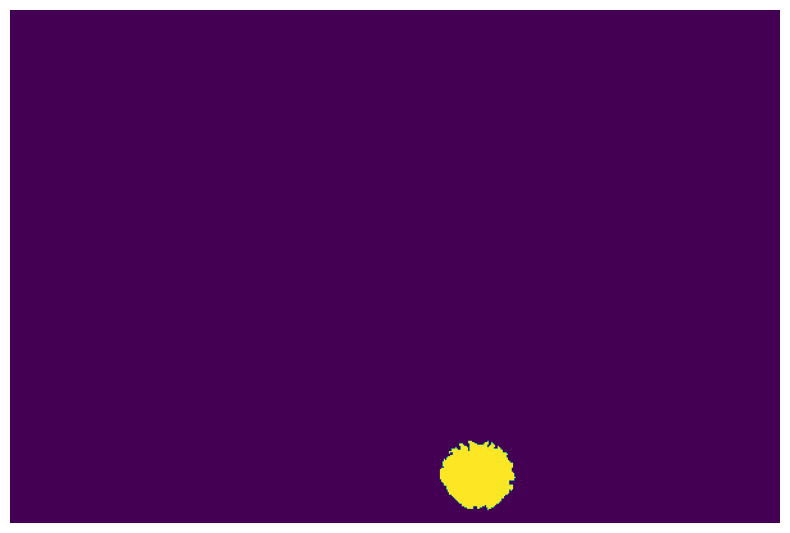

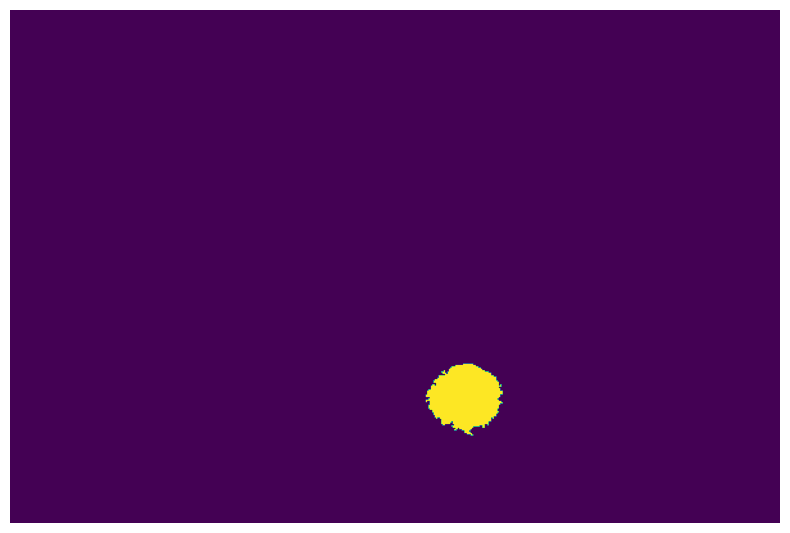

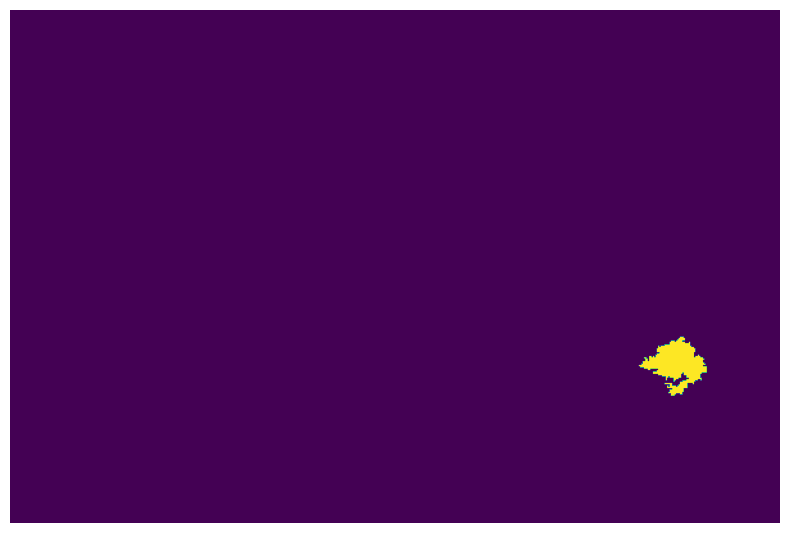

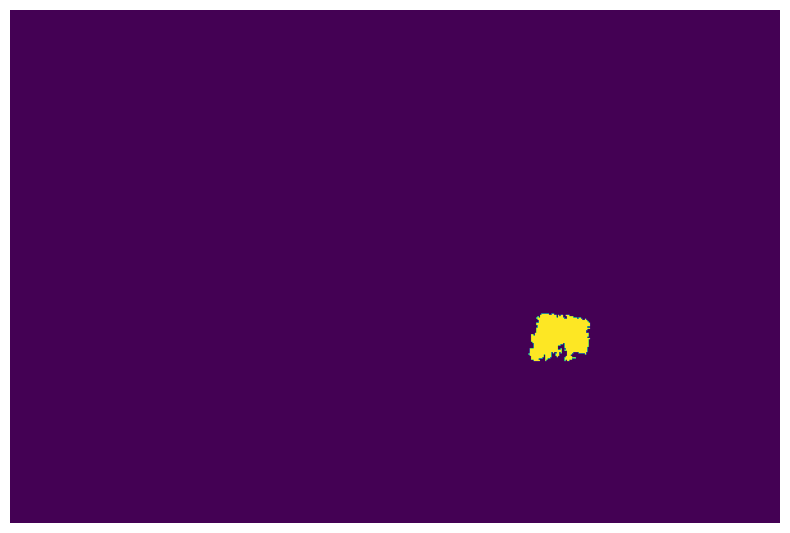

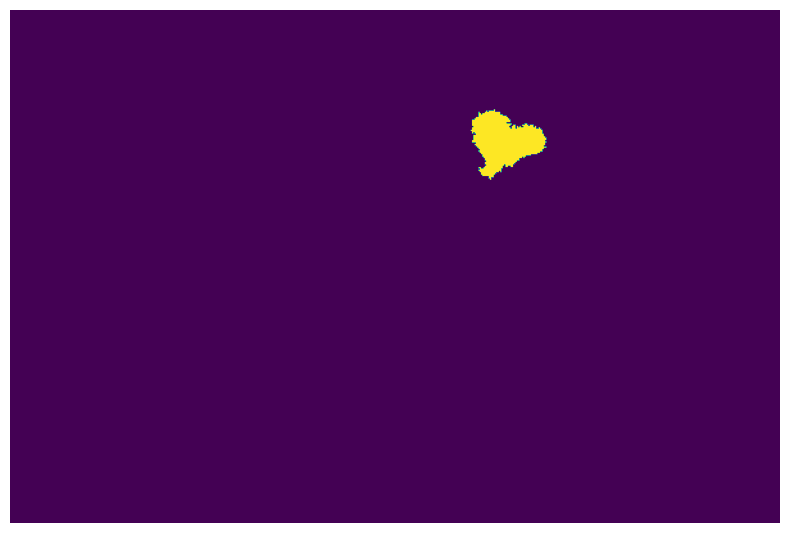

In [39]:
for contour in contours:

    masque = np.zeros_like(processed)

    cv2.drawContours(masque, [contour], -1, 255, thickness=cv2.FILLED)

    plt.figure(figsize=(8, 8))
    #plt.imshow(binned)
    plt.imshow(masque)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [40]:
# table with name of chocolate
chocolates = {
    0: 'amandina',
    1: 'arabia',
    2: 'comtesse',
    3: 'creme_brulee',
    4: 'jelly_black',
    5: 'jelly_milk',
    6: 'jelly_white',
    7: 'noblesse_annoted',
    8: 'noir_authentique',
    9: 'passion_au_lait',
    10: 'stracciatella',
    11: 'tentation_noir',
    12: 'triangolo'
}

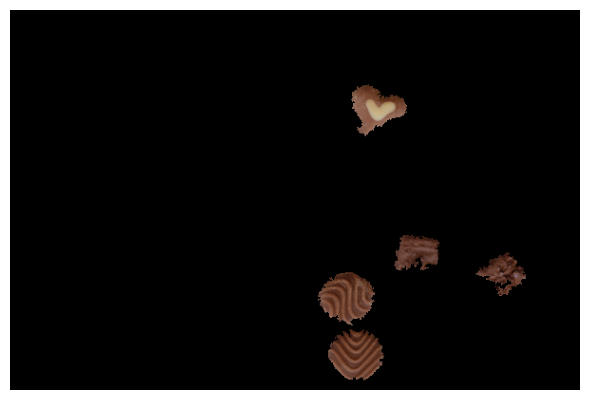

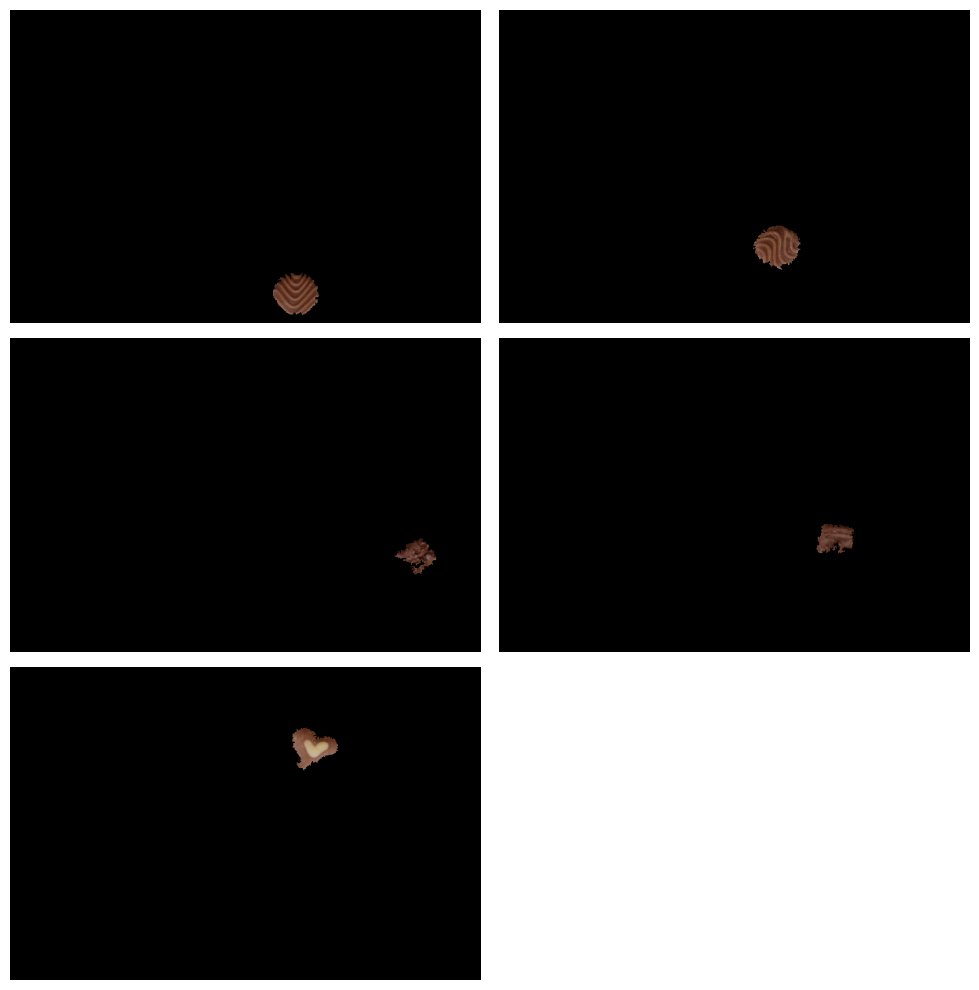

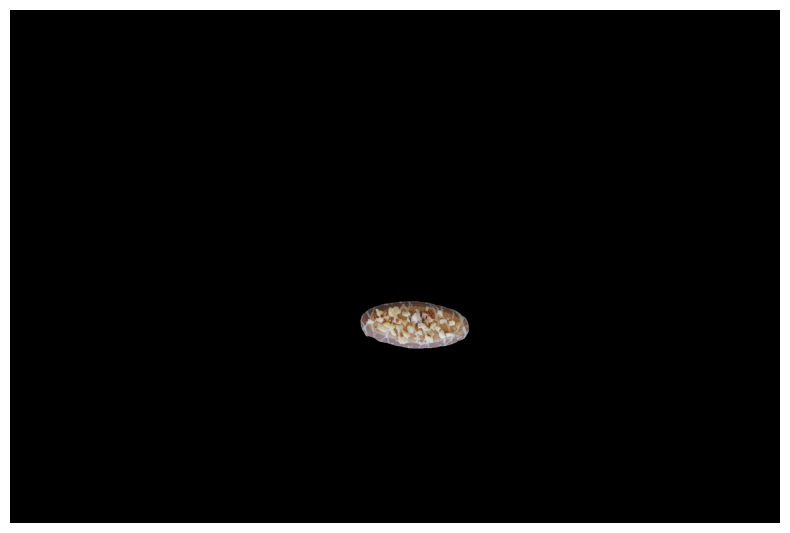

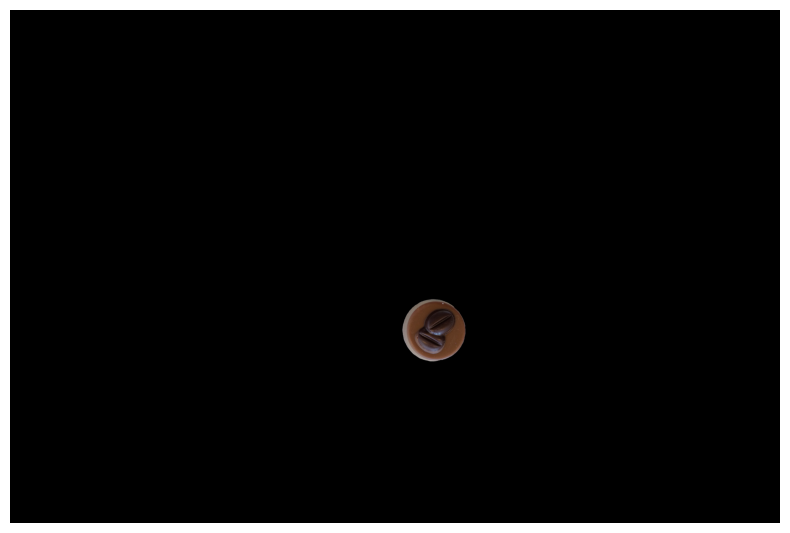

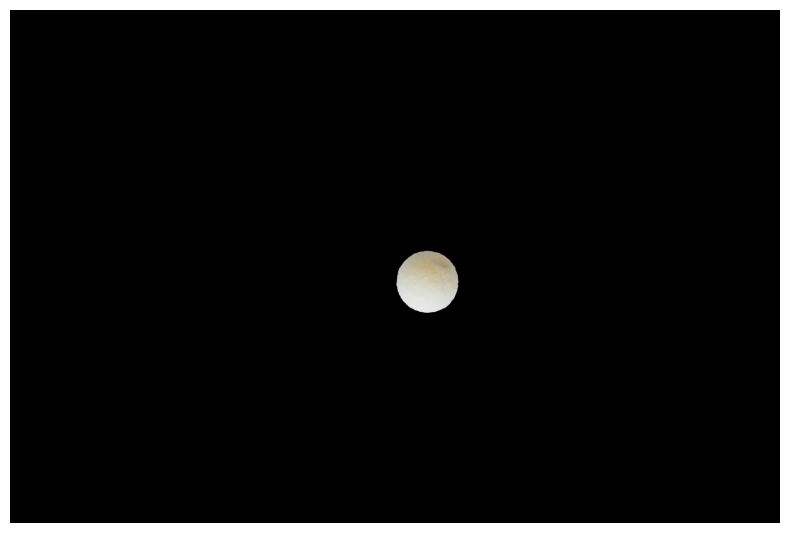

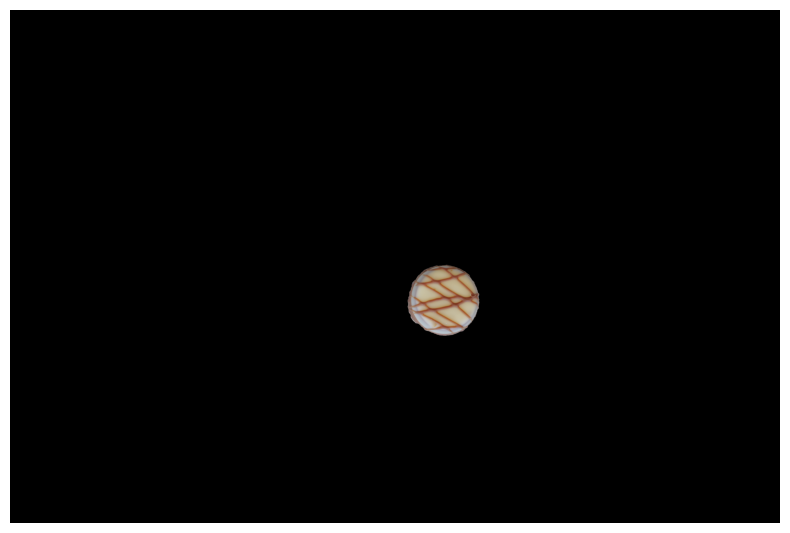

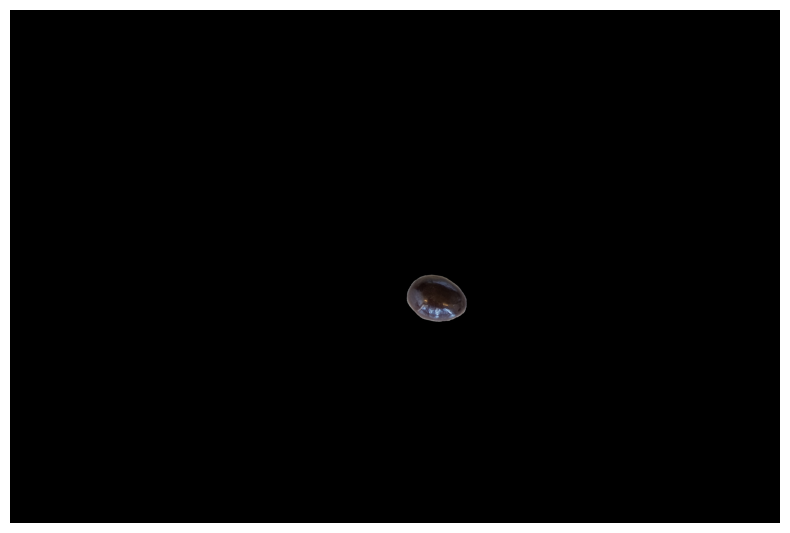

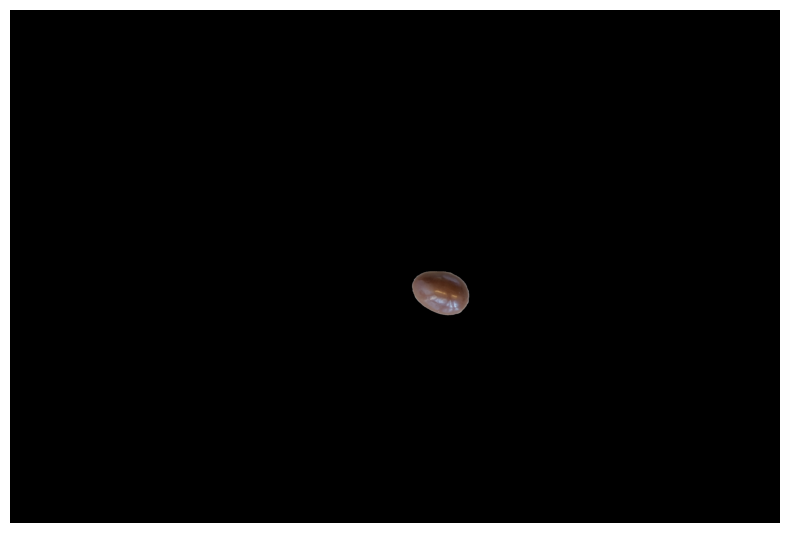

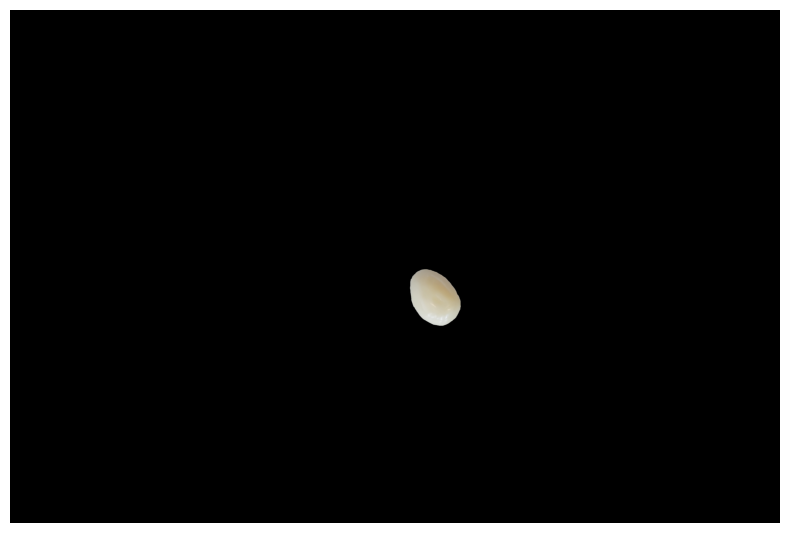

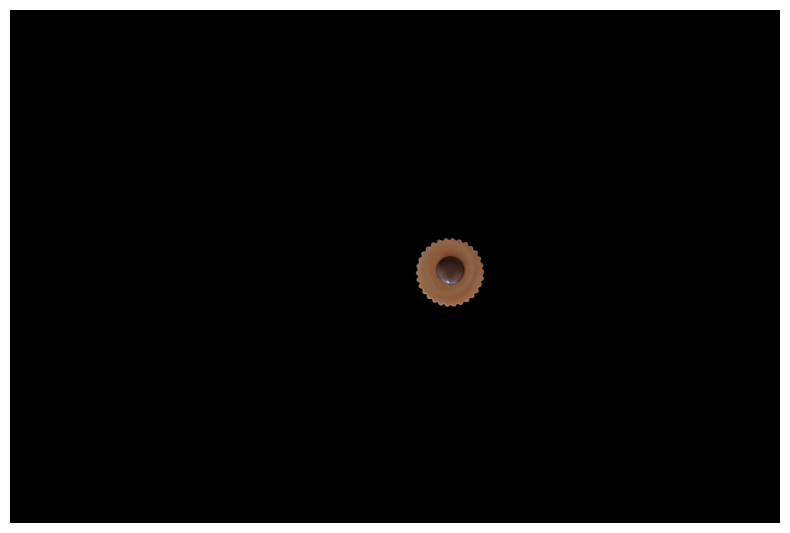

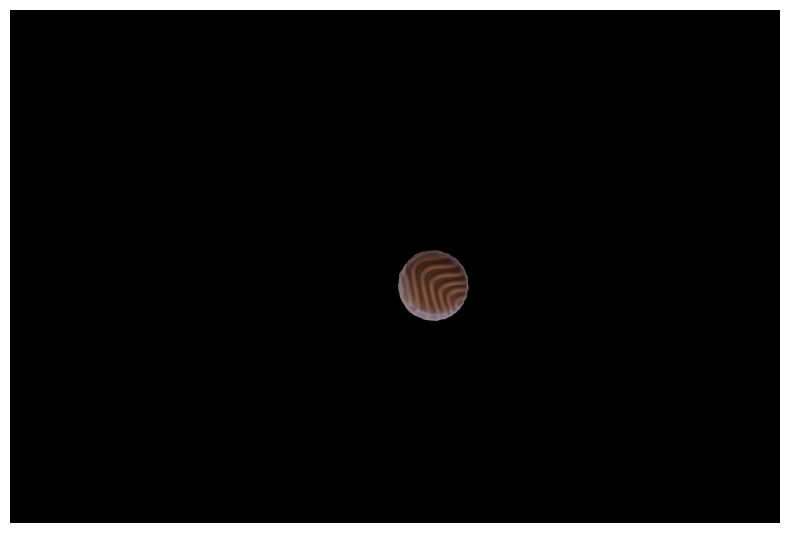

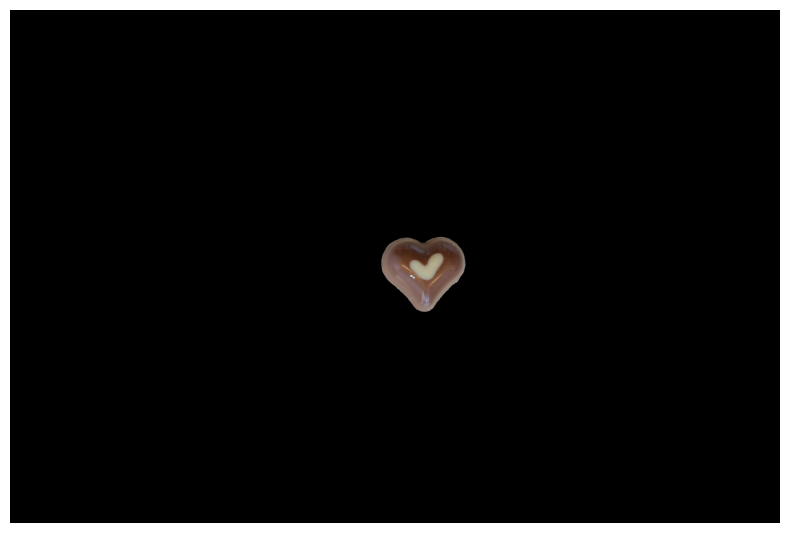

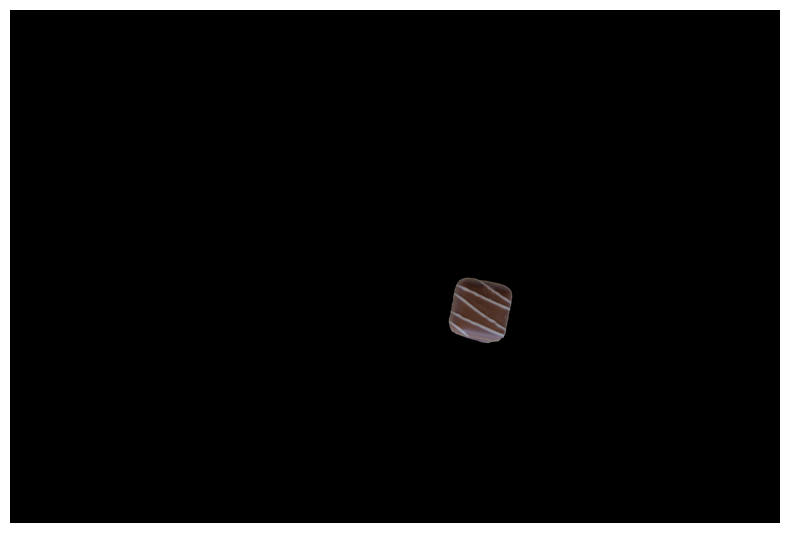

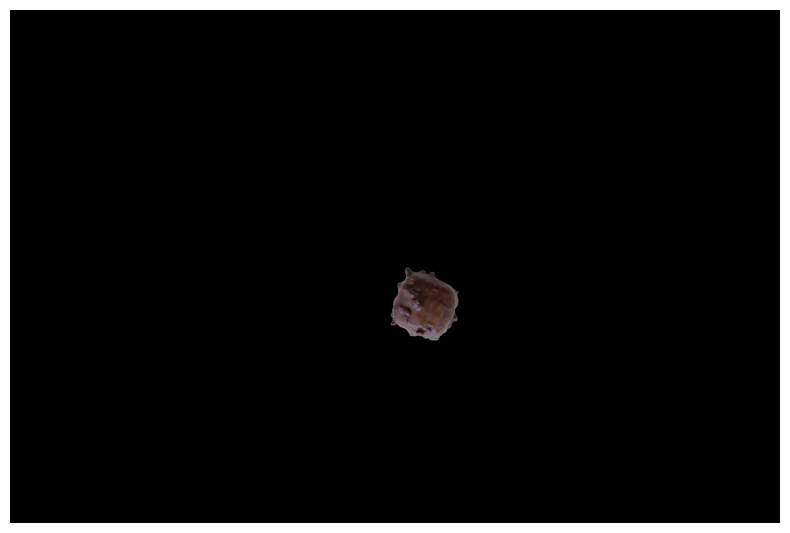

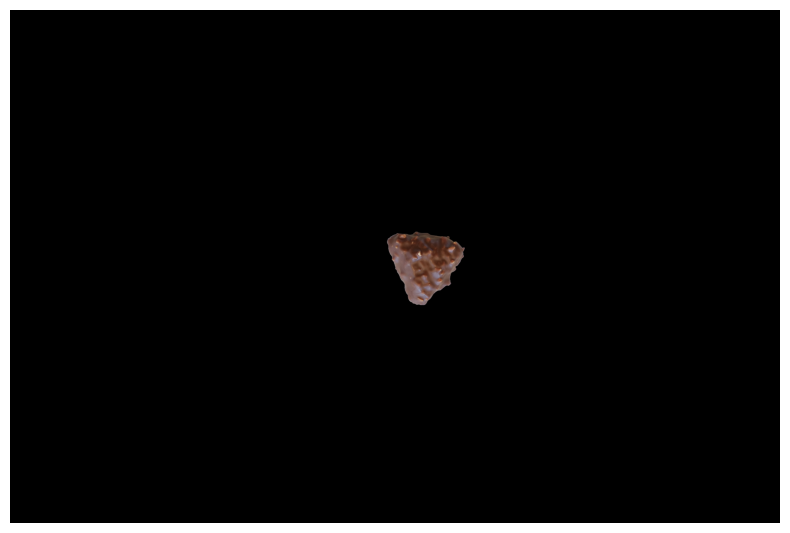

C:\Users\mikae\AppData\Local\Temp\ipykernel_26464\3974856611.py:74: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', 13)


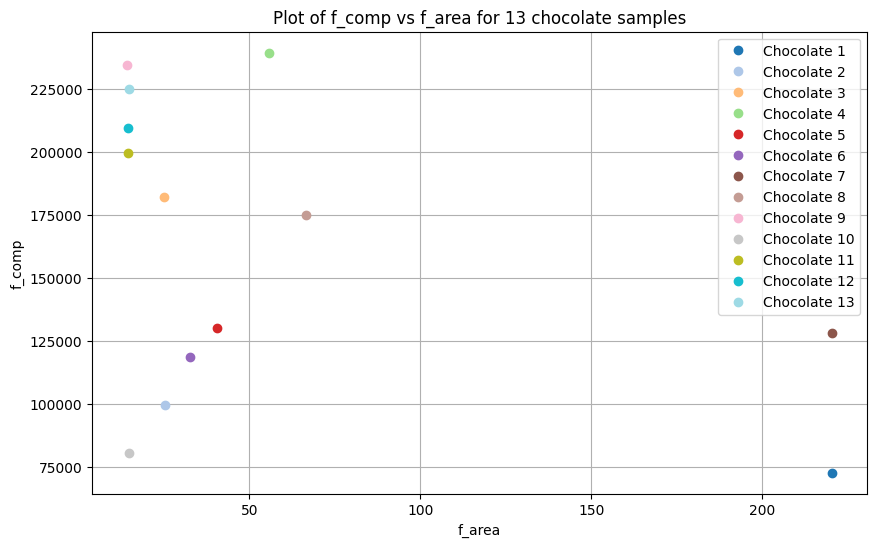

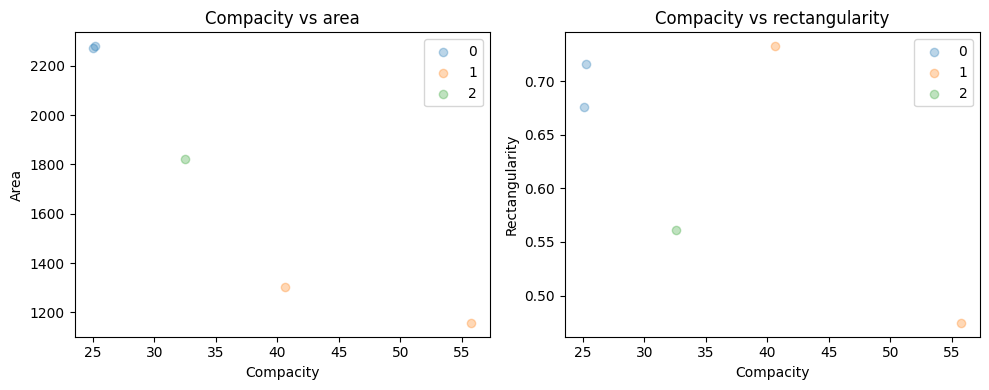

In [ ]:
masque = np.zeros_like(processed)

cv2.drawContours(masque, contours, -1, 255, thickness= cv2.FILLED)
chocolate = np.zeros_like(binned)
N, M, _ = binned.shape
for x in range(N):
    for y in range(M):
        if masque[x, y] != 0:
            chocolate[x, y, :] = binned[x, y, :]
plt.figure(figsize=(6, 6))
plt.imshow(chocolate)
plt.axis('off')
plt.tight_layout()
plt.show()

count_pixel = []
diff_object = []
plt.figure(figsize=(10, 10))
i = 0
f_peri = []
f_area = []
f_comp = []
f_rect = []
for contour in contours:
    count_pixel.append(0)
    masque = np.zeros_like(processed)
    cv2.drawContours(masque, [contour], -1, 255, thickness= cv2.FILLED)
    chocolate = np.zeros_like(binned)
    N, M, _ = binned.shape
    for x in range(N):
        for y in range(M):
            if masque[x, y] != 0:
                chocolate[x, y, :] = binned[x, y, :]
                count_pixel[i] += 1
    diff_object.append(chocolate)
    i += 1
    plt.subplot(3, 2, i)
    plt.imshow(chocolate)
    plt.axis('off')
    properties = regionprops(label_image=masque)
    f_peri.append(properties[0].perimeter)
    f_area.append(properties[0].area)
    f_comp.append(f_peri[i - 1]**2/f_area[i - 1])
    f_rect.append(f_area[i - 1]/properties[0].area_bbox)

plt.tight_layout()

plt.show()

nb_pixels = []
choco = [np.zeros_like(ref[i]) for i in range(len(ref))]

for i in range(len(ref)):
    count_pixel = 0
    N, M = ref_annotated[i].shape
    for x in range(N):
        for y in range(M):
            if ref_annotated[i][x, y] != 0:
                choco[i][x, y, :] = ref[i][x, y, :]
                count_pixel += 1
    nb_pixels.append(count_pixel)

    properties = regionprops(label_image=ref_annotated[i])
    f_peri.append(properties[0].perimeter)
    f_area.append(properties[0].area)
    f_comp.append(f_peri[i - 1]**2/f_area[i - 1])
    f_rect.append(f_area[i - 1]/properties[0].area_bbox)
    plt.figure(figsize=(8, 8))
    plt.imshow(choco[i])
    plt.axis('off')
    plt.tight_layout()
    plt.show()

colors = plt.cm.get_cmap('tab20', 13)
plt.figure(figsize=(10, 6))
for i in range(len(ref)):
    plt.plot(f_comp[i+5], f_rect[i+5], 'o', color=colors(i), label=f'Chocolate {i+1}')

plt.xlabel('f_area')
plt.ylabel('f_comp')
plt.title('Plot of f_comp vs f_rect for 13 chocolate samples')
plt.legend()
plt.grid(True)
plt.show()


_, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter([f_comp[0], f_comp[1]], [f_area[0], f_area[1]], label=0, alpha=0.3)
axes[0].scatter([f_comp[2], f_comp[3]], [f_area[2], f_area[3]], label=1, alpha=0.3)
axes[0].scatter(f_comp[4], f_area[4], label=2, alpha=0.3)
axes[0].set_xlabel("Compacity")
axes[0].set_ylabel("Area")
axes[0].set_title("Compacity vs area")
axes[0].legend()

# compacity vs rectangularity
axes[1].scatter([f_comp[0], f_comp[1]], [f_rect[0], f_rect[1]], label=0, alpha=0.3)
axes[1].scatter([f_comp[2], f_comp[3]], [f_rect[2], f_rect[3]], label=1, alpha=0.3)
axes[1].scatter(f_comp[4], f_rect[4], label=2, alpha=0.3)
axes[1].set_xlabel("Compacity")
axes[1].set_ylabel("Rectangularity")
axes[1].set_title("Compacity vs rectangularity")
axes[1].legend()

plt.tight_layout()





In [163]:
array_sum = []
for n in range(len(diff_object)):
    sum = 0
    sum = np.sum(diff_object[n])/count_pixel[n]
    array_sum.append(sum)
    print(sum)

sum_passion_au_lait = np.sum(passion_au_lait)/count_pixel_passion_au_lait
sum_tentation_noir = np.sum(tentation_noir)/count_pixel_tentation_noir
sum_noir_authentique = np.sum(noir_authentique)/count_pixel_noir_authentique

print(sum_passion_au_lait)
print(sum_tentation_noir)
print(sum_noir_authentique)

choc_passion_au_lait = 0
choc_tentation_noir = 0
choc_noir_authentique = 0

for n in range(len(array_sum)):
    if ((sum_passion_au_lait - 20) < array_sum[n]) & ((sum_passion_au_lait + 20) > array_sum[n]):
        choc_passion_au_lait += 1
    if ((sum_tentation_noir - 20) < array_sum[n]) & ((sum_tentation_noir + 20) > array_sum[n]):
        choc_tentation_noir += 1
    if ((sum_noir_authentique - 20) < array_sum[n]) & ((sum_noir_authentique + 20) > array_sum[n]):
        choc_noir_authentique += 1

print(choc_passion_au_lait, choc_tentation_noir, choc_noir_authentique)


207.4840493407061
298.91305264822967
204.43648876967575
227.14870611518924
0 1 1
